# 🧪 Evaluasi Model — MobileNetV4 + ECA-Net (Fusion)
Notebook ini **hanya untuk evaluasi/testing** model yang sudah ditraining.

**Urutan menjalankan:** jalankan semua cell dari atas ke bawah secara berurutan.

# 1. Install Package

In [1]:
!pip install -q timm
!pip install -q scikit-learn matplotlib seaborn opencv-python albumentations pandas
print('✅ Install selesai')

✅ Install selesai


# 2. Import Package

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

import numpy as np
import pandas as pd
import os
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print('✅ Semua package berhasil diimport')

✅ Semua package berhasil diimport


# 3. Set Random Seed

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print('✅ Random seed = 42')

✅ Random seed = 42


# 4. Config
> ⚠️ Sesuaikan `BASE_PATH` dan `MODEL_PATH` dengan lokasi file Anda di Google Drive.

In [4]:
class Config:

    # ========== PATH ==========
    # BASE_PATH  = "/content/drive/MyDrive/dataset801010"          # ⚠️ folder dataset (ada /mata dan /insang)
    BASE_PATH  = "/content/drive/MyDrive/datatest"          # ⚠️ folder dataset (ada /mata dan /insang)
    MODEL_PATH = "/content/drive/MyDrive/hasilv3/Models/SGD/EcaNett/checkpoints_fusion/best_model.pth"  # ⚠️ path model .pth
    SAVE_PATH  = "/content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22"  # folder output hasil evaluasi

    # ========== MODEL (harus sama persis dengan saat training) ==========
    MODEL_NAME      = 'mobilenetv4_conv_small'
    NUM_CLASSES     = 2
    IMG_SIZE        = 96    # ⚠️ harus sama dengan saat training
    FUSION_METHOD   = 'concat'
    ECA_POSITIONS   = [8, 12, 16]
    DROPOUT_RATE    = 0.2

    # ========== PREPROCESSING (harus sama dengan saat training) ==========
    APPLY_CLAHE      = True
    CLAHE_CLIP_LIMIT = 2.0
    CLAHE_TILE_SIZE  = (8, 8)
    MEAN             = [0.485, 0.456, 0.406]
    STD              = [0.229, 0.224, 0.225]

    # ========== DATALOADER ==========
    BATCH_SIZE   = 32
    NUM_WORKERS  = 0
    FEATURE_TYPE = 'fusion'

    # ========== ECA-NET ==========
    USE_ECA_NET = True  # ← True: evaluasi model dengan ECA-Net | False: tanpa ECA-Net

    # ========== DEVICE ==========
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()
print(f'✅ Config loaded')
print(f'   Device      : {config.DEVICE}')
print(f'   IMG_SIZE    : {config.IMG_SIZE}')
print(f'   MODEL_PATH  : {config.MODEL_PATH}')
print(f'   USE_ECA_NET : {config.USE_ECA_NET}')
print(f'   SAVE_PATH   : {config.SAVE_PATH}')

✅ Config loaded
   Device      : cpu
   IMG_SIZE    : 96
   MODEL_PATH  : /content/drive/MyDrive/hasilv3/Models/SGD/EcaNett/checkpoints_fusion/best_model.pth
   USE_ECA_NET : True
   SAVE_PATH   : /content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22


# 5. Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Verifikasi dataset
print('\n📁 Verifikasi dataset dan model...')
ok = True
for feature in ['mata', 'insang']:
    for cls in ['segar', 'tidak_segar']:
        path = os.path.join(config.BASE_PATH, feature, 'test', cls)
        if os.path.exists(path):
            n = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
            print(f'   ✅ {feature}/test/{cls}: {n} gambar')
        else:
            print(f'   ❌ TIDAK DITEMUKAN: {path}')
            ok = False

# Verifikasi model
if os.path.exists(config.MODEL_PATH):
    size_mb = os.path.getsize(config.MODEL_PATH) / (1024*1024)
    print(f'\n   ✅ Model ditemukan: {config.MODEL_PATH} ({size_mb:.1f} MB)')
else:
    print(f'\n   ❌ Model tidak ditemukan: {config.MODEL_PATH}')
    ok = False

if ok:
    print('\n✅ Semua file siap. Lanjutkan ke cell berikutnya.')
else:
    print('\n⚠️  Ada file yang tidak ditemukan. Periksa kembali path di Config.')

Mounted at /content/drive

📁 Verifikasi dataset dan model...
   ✅ mata/test/segar: 86 gambar
   ✅ mata/test/tidak_segar: 86 gambar
   ✅ insang/test/segar: 86 gambar
   ✅ insang/test/tidak_segar: 86 gambar

   ✅ Model ditemukan: /content/drive/MyDrive/hasilv3/Models/SGD/EcaNett/checkpoints_fusion/best_model.pth (48.5 MB)

✅ Semua file siap. Lanjutkan ke cell berikutnya.


# 6. CLAHE & Transform (Test)

In [6]:
def apply_clahe(image, clip_limit=2.0, tile_size=(8, 8)):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge([l_clahe, a, b])
    return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)


class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_size  = tile_size

    def __call__(self, image, **kwargs):
        return apply_clahe(image, self.clip_limit, self.tile_size)


def get_test_transforms(img_size=config.IMG_SIZE, apply_clahe_flag=True):
    """Transform untuk test — tanpa augmentasi, sama dengan valid transform saat training."""
    transforms_list = []

    if apply_clahe_flag:
        transforms_list.append(A.Lambda(
            image=CLAHETransform(
                clip_limit=config.CLAHE_CLIP_LIMIT,
                tile_size=config.CLAHE_TILE_SIZE
            ),
            name='CLAHE'
        ))

    transforms_list += [
        A.Normalize(mean=config.MEAN, std=config.STD, max_pixel_value=255.0),
        ToTensorV2()
    ]

    return A.Compose(transforms_list)


print('✅ CLAHE & transform siap')

✅ CLAHE & transform siap


# 7. Dataset & Dataloader

In [7]:
class IkanNilaDataset(Dataset):

    def __init__(self, data_dir, feature_type='fusion', split='test',
                 transform=None, img_size=config.IMG_SIZE):
        self.data_dir     = data_dir
        self.feature_type = feature_type
        self.split        = split
        self.transform    = transform
        self.img_size     = img_size
        self.class_to_idx = {'segar': 0, 'tidak_segar': 1}
        self.idx_to_class = {0: 'segar', 1: 'tidak_segar'}
        self.data_list    = []
        self._load_data()
        print(f'✅ Dataset loaded: {len(self.data_list)} samples | {feature_type} | {split}')

    def _load_data(self):
        if self.feature_type in ['mata', 'insang']:
            feature_dir = os.path.join(self.data_dir, self.feature_type, self.split)
            for class_name in ['segar', 'tidak_segar']:
                class_dir = os.path.join(feature_dir, class_name)
                if not os.path.exists(class_dir):
                    print(f'⚠️  Tidak ditemukan: {class_dir}')
                    continue
                image_files = []
                for ext in ['*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG']:
                    image_files.extend(list(Path(class_dir).glob(ext)))
                for img_path in image_files:
                    self.data_list.append({
                        'path': str(img_path), 'label': self.class_to_idx[class_name],
                        'class_name': class_name, 'filename': img_path.name,
                        'mata_path': str(img_path), 'insang_path': str(img_path)
                    })

        elif self.feature_type == 'fusion':
            mata_dir   = os.path.join(self.data_dir, 'mata',   self.split)
            insang_dir = os.path.join(self.data_dir, 'insang', self.split)
            for class_name in ['segar', 'tidak_segar']:
                mata_class_dir   = os.path.join(mata_dir,   class_name)
                insang_class_dir = os.path.join(insang_dir, class_name)
                mata_files, insang_files = {}, {}
                for ext in ['*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG']:
                    for f in Path(mata_class_dir).glob(ext):
                        mata_files[f.stem.replace('mata_', '')] = str(f)
                    for f in Path(insang_class_dir).glob(ext):
                        insang_files[f.stem.replace('insang_', '')] = str(f)
                for base_name in mata_files:
                    if base_name in insang_files:
                        self.data_list.append({
                            'mata_path'  : mata_files[base_name],
                            'insang_path': insang_files[base_name],
                            'label'      : self.class_to_idx[class_name],
                            'class_name' : class_name,
                            'filename'   : base_name
                        })
                    else:
                        print(f'⚠️  Tidak ada pasangan insang untuk: {base_name}')

    def _load_and_preprocess(self, image_path):
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f'Gagal load: {image_path}')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        return image

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        d     = self.data_list[idx]
        label = d['label']
        if self.feature_type == 'fusion':
            mata_img   = self._load_and_preprocess(d['mata_path'])
            insang_img = self._load_and_preprocess(d['insang_path'])
            if self.transform:
                mata_img   = self.transform(image=mata_img)['image']
                insang_img = self.transform(image=insang_img)['image']
            return (mata_img, insang_img), label
        else:
            image = self._load_and_preprocess(d['path'])
            if self.transform:
                image = self.transform(image=image)['image']
            return image, label

    def get_class_distribution(self):
        dist = {'segar': 0, 'tidak_segar': 0}
        for d in self.data_list:
            dist[d['class_name']] += 1
        return dist


# Buat test dataloader
test_transform = get_test_transforms(img_size=config.IMG_SIZE, apply_clahe_flag=config.APPLY_CLAHE)

test_dataset = IkanNilaDataset(
    data_dir=config.BASE_PATH, feature_type=config.FEATURE_TYPE,
    split='test', transform=test_transform, img_size=config.IMG_SIZE
)

test_loader = DataLoader(
    test_dataset, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=config.NUM_WORKERS,
    pin_memory=True, drop_last=False
)

dataloaders = {'test': test_loader}

dist  = test_dataset.get_class_distribution()
total = sum(dist.values())
print(f'\n📊 TEST DATASET')
print(f'   Total       : {total} samples')
print(f'   Segar       : {dist["segar"]} ({dist["segar"]/total*100:.1f}%)')
print(f'   Tidak Segar : {dist["tidak_segar"]} ({dist["tidak_segar"]/total*100:.1f}%)')
print(f'   Batch size  : {config.BATCH_SIZE} | Batches: {len(test_loader)}')

✅ Dataset loaded: 172 samples | fusion | test

📊 TEST DATASET
   Total       : 172 samples
   Segar       : 86 (50.0%)
   Tidak Segar : 86 (50.0%)
   Batch size  : 32 | Batches: 6


# 8. Definisi Arsitektur Model

In [8]:
class ECALayer(nn.Module):

    def __init__(self, channels, gamma=2, b=1):
        super(ECALayer, self).__init__()
        t = int(abs((np.log2(channels) + b) / gamma))
        k = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k, padding=(k-1)//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x).squeeze(-1).transpose(-1, -2)
        y = self.sigmoid(self.conv(y)).transpose(-1, -2).unsqueeze(-1)
        return x * y.expand_as(x)


class MobileNetV4WithOptionalECA(nn.Module):
    """
    Arsitektur harus identik dengan saat training.
    use_eca dikontrol dari config.USE_ECA_NET:
      - True  → ECA disisipkan di dalam setiap stage backbone
      - False → MobileNetV4 saja (baseline)
    """

    def __init__(self, model_name, num_classes=2, fusion_method='concat',
                 use_eca=True, dropout_rate=0.5,
                 pretrained=False, freeze_backbone=False):
        super().__init__()
        self.fusion_method = fusion_method
        self.use_eca = use_eca

        print(f"   ECA-Net: {'✅ ENABLED (di dalam setiap stage backbone)' if use_eca else '❌ DISABLED (baseline)'}")

        self.backbone_mata   = self._create_backbone(model_name, pretrained, use_eca)
        self.backbone_insang = self._create_backbone(model_name, pretrained, use_eca)

        with torch.no_grad():
            dummy = torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE)
            self.feature_dim = self.backbone_mata(dummy).shape[1]

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        if fusion_method == 'concat':
            fusion_dim  = self.feature_dim * 2
            self.fusion = None
        elif fusion_method == 'add':
            fusion_dim  = self.feature_dim
            self.fusion = None
        elif fusion_method == 'attention':
            fusion_dim  = self.feature_dim * 2
            self.fusion = nn.Sequential(
                nn.Linear(fusion_dim, fusion_dim // 2), nn.ReLU(inplace=True),
                nn.Linear(fusion_dim // 2, 2), nn.Softmax(dim=1)
            )

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(fusion_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes)
        )

    def _create_backbone(self, model_name, pretrained, use_eca):
        backbone = timm.create_model(model_name, pretrained=pretrained,
                                     num_classes=0, global_pool='')

        if not use_eca:
            class BackboneOnly(nn.Module):
                def __init__(self, bb):
                    super().__init__()
                    self.backbone = bb
                def forward(self, x):
                    return self.backbone(x)
            return BackboneOnly(backbone)

        # Deteksi channel setiap stage
        stage_outputs = {}
        hooks = []
        def make_hook(idx):
            def hook(m, inp, out):
                if isinstance(out, torch.Tensor):
                    stage_outputs[idx] = out.shape[1]
            return hook
        for i, stage in enumerate(backbone.blocks):
            hooks.append(stage.register_forward_hook(make_hook(i)))
        with torch.no_grad():
            backbone(torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE))
        for h in hooks:
            h.remove()
        stage_channels = [stage_outputs[i] for i in range(len(backbone.blocks))]

        class BackboneWithInternalECA(nn.Module):
            def __init__(self, bb, stage_ch):
                super().__init__()
                self.conv_stem  = bb.conv_stem
                self.bn1        = bb.bn1
                self.stages     = nn.ModuleList(bb.blocks)
                self.eca_layers = nn.ModuleList([ECALayer(ch) for ch in stage_ch])
                self.conv_head  = bb.conv_head
                self.norm_head  = bb.norm_head
            def forward(self, x):
                x = self.conv_stem(x)
                x = self.bn1(x)
                for stage, eca in zip(self.stages, self.eca_layers):
                    x = stage(x)
                    x = eca(x)
                x = self.conv_head(x)
                x = self.norm_head(x)
                return x

        return BackboneWithInternalECA(backbone, stage_channels)

    def forward(self, x):
        mata_img, insang_img = x
        feat_mata   = self.global_pool(self.backbone_mata(mata_img)).flatten(1)
        feat_insang = self.global_pool(self.backbone_insang(insang_img)).flatten(1)
        if self.fusion_method == 'concat':
            fused = torch.cat([feat_mata, feat_insang], dim=1)
        elif self.fusion_method == 'add':
            fused = feat_mata + feat_insang
        elif self.fusion_method == 'attention':
            concat_feat       = torch.cat([feat_mata, feat_insang], dim=1)
            attention_weights = self.fusion(concat_feat)
            fused = attention_weights[:,0:1] * feat_mata + attention_weights[:,1:2] * feat_insang
        return self.classifier(fused)

    def get_num_parameters(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return {'total': total, 'trainable': trainable}


# Alias backward compatibility
MobileNetV4_ECANet = MobileNetV4WithOptionalECA

print('✅ Arsitektur model terdefinisi')
print('   → USE_ECA_NET = True  : ECA disisipkan di dalam setiap stage backbone')
print('   → USE_ECA_NET = False : MobileNetV4 tanpa ECA-Net (baseline)')


✅ Arsitektur model terdefinisi
   → USE_ECA_NET = True  : ECA disisipkan di dalam setiap stage backbone
   → USE_ECA_NET = False : MobileNetV4 tanpa ECA-Net (baseline)


# 9. Build & Load Model

In [9]:
# Build model dengan arsitektur identik saat training
# ⚠️ Pastikan USE_ECA_NET di Config sesuai dengan model yang ingin dievaluasi
model = MobileNetV4WithOptionalECA(
    model_name    =config.MODEL_NAME,
    num_classes   =config.NUM_CLASSES,
    fusion_method =config.FUSION_METHOD,
    use_eca       =config.USE_ECA_NET,        # ← dari config
    dropout_rate  =config.DROPOUT_RATE,
    pretrained    =False,
    freeze_backbone=False
)
model.to(config.DEVICE)

# Load weights dari checkpoint
print('📂 Loading model weights...')
checkpoint = torch.load(config.MODEL_PATH, map_location=config.DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

eca_status = "dengan ECA-Net" if config.USE_ECA_NET else "tanpa ECA-Net (baseline)"
print(f'✅ Model ({eca_status}) berhasil di-load!')
print(f'   Dari epoch  : {checkpoint["epoch"]}')
print(f'   Valid Loss  : {checkpoint["valid_loss"]:.4f}')
print(f'   Valid Acc   : {checkpoint["valid_acc"]:.2f}%')

params = model.get_num_parameters()
print(f'\n📊 Model Parameters:')
print(f'   Total  : {params["total"]:,}')
print(f'   Size   : ~{params["total"]*4/1024/1024:.2f} MB')


   ECA-Net: ✅ ENABLED (di dalam setiap stage backbone)
📂 Loading model weights...
✅ Model (dengan ECA-Net) berhasil di-load!
   Dari epoch  : 9
   Valid Loss  : 0.0319
   Valid Acc   : 91.86%

📊 Model Parameters:
   Total  : 6,299,368
   Size   : ~24.03 MB


# 10. Fungsi Evaluasi

In [10]:
def evaluate(model, dataloader, device):
    """
    Evaluasi model pada dataloader.
    Selain metrik agregat, kembalikan juga info per-sample
    (filename, mata_path, insang_path, true_label, pred_label, confidence, status)
    untuk disimpan ke CSV.
    """
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    per_sample_records = []

    sample_idx = 0
    pbar = tqdm(dataloader, desc='[TEST]', leave=True)

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(pbar):
            mata_img, insang_img = images
            mata_img   = mata_img.to(device, non_blocking=True)
            insang_img = insang_img.to(device, non_blocking=True)
            labels     = labels.to(device, non_blocking=True)

            outputs = model((mata_img, insang_img))
            probs   = torch.softmax(outputs, dim=1)
            preds   = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            # Rekam info per sample
            class_names = ['Segar', 'Tidak Segar']
            for i in range(len(labels)):
                d          = dataloader.dataset.data_list[sample_idx]
                true_lbl   = labels[i].item()
                pred_lbl   = preds[i].item()
                prob_segar = probs[i][0].item()
                prob_tidak = probs[i][1].item()
                conf       = probs[i][pred_lbl].item()
                is_correct = (true_lbl == pred_lbl)

                per_sample_records.append({
                    'sample_index'       : sample_idx + 1,
                    'filename'           : d.get('filename', ''),
                    'mata_path'          : d.get('mata_path', d.get('path', '')),
                    'insang_path'        : d.get('insang_path', d.get('path', '')),
                    'true_label_id'      : true_lbl,
                    'true_label'         : class_names[true_lbl],
                    'pred_label_id'      : pred_lbl,
                    'pred_label'         : class_names[pred_lbl],
                    'prob_segar'         : round(prob_segar, 4),
                    'prob_tidak_segar'   : round(prob_tidak, 4),
                    'confidence'         : round(conf, 4),
                    'is_correct'         : is_correct,
                    'status'             : 'BENAR' if is_correct else 'SALAH'
                })
                sample_idx += 1

            pbar.set_postfix({
                'Acc': f'{sum(r["is_correct"] for r in per_sample_records)/len(per_sample_records)*100:.2f}%'
            })

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    acc    = accuracy_score(y_true, y_pred) * 100

    return {
        'acc'            : acc,
        'y_true'         : y_true,
        'y_pred'         : y_pred,
        'y_proba'        : y_prob[:, 1],
        'per_sample'     : per_sample_records
    }

print('✅ Fungsi evaluate() siap')

✅ Fungsi evaluate() siap


# 11. Jalankan Evaluasi

In [11]:
os.makedirs(config.SAVE_PATH, exist_ok=True)

print('🧪 Mengevaluasi model pada test set...\n')
results = evaluate(model, dataloaders['test'], config.DEVICE)

y_true  = results['y_true']
y_pred  = results['y_pred']
y_proba = results['y_proba']

print('\n' + '='*70)
print('🎯 TEST SET RESULTS')
print('='*70)
print(f'Test Accuracy : {results["acc"]:.2f}%')
print(f'Total Sampel  : {len(y_true)}')
print(f'Benar         : {int((y_true == y_pred).sum())}')
print(f'Salah         : {int((y_true != y_pred).sum())}')
print('='*70)

🧪 Mengevaluasi model pada test set...



[TEST]:   0%|          | 0/6 [00:00<?, ?it/s]


🎯 TEST SET RESULTS
Test Accuracy : 69.77%
Total Sampel  : 172
Benar         : 120
Salah         : 52


# 12. Simpan Hasil Prediksi ke CSV
File CSV berisi **semua sampel test** beserta:
- `sample_index` — nomor urut sampel
- `filename` — nama file gambar
- `mata_path` / `insang_path` — path lengkap gambar
- `true_label` / `pred_label` — label asli dan prediksi
- `prob_segar` / `prob_tidak_segar` — probabilitas tiap kelas
- `confidence` — keyakinan model (probabilitas kelas yang dipilih)
- `status` — `BENAR` atau `SALAH`

In [12]:
df_all = pd.DataFrame(results['per_sample'])

# Pisahkan dataframe benar dan salah
df_benar = df_all[df_all['is_correct'] == True].reset_index(drop=True)
df_salah = df_all[df_all['is_correct'] == False].reset_index(drop=True)

# Simpan ke CSV
csv_all    = os.path.join(config.SAVE_PATH, 'prediksi_semua_sampel.csv')
csv_benar  = os.path.join(config.SAVE_PATH, 'prediksi_benar.csv')
csv_salah  = os.path.join(config.SAVE_PATH, 'prediksi_salah.csv')

df_all.to_csv(csv_all,   index=False)
df_benar.to_csv(csv_benar, index=False)
df_salah.to_csv(csv_salah, index=False)

print(f'💾 Semua sampel  ({len(df_all):>4} baris) → {csv_all}')
print(f'💾 Prediksi benar({len(df_benar):>4} baris) → {csv_benar}')
print(f'💾 Prediksi salah({len(df_salah):>4} baris) → {csv_salah}')

# Preview 5 baris pertama
print('\n📋 Preview df_all (5 baris pertama):')
display(df_all.head())

if len(df_salah) > 0:
    print(f'\n📋 Sampel yang SALAH ({len(df_salah)} sampel):')
    display(df_salah[['sample_index','filename','true_label','pred_label','confidence','status']])
else:
    print('\n🎉 Tidak ada sampel yang salah!')

💾 Semua sampel  ( 172 baris) → /content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22/prediksi_semua_sampel.csv
💾 Prediksi benar( 120 baris) → /content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22/prediksi_benar.csv
💾 Prediksi salah(  52 baris) → /content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22/prediksi_salah.csv

📋 Preview df_all (5 baris pertama):


,sample_index,filename,mata_path,insang_path,true_label_id,true_label,pred_label_id,pred_label,prob_segar,prob_tidak_segar,confidence,is_correct,status
0,1,segar_001,/content/drive/MyDrive/datatest/mata/test/sega...,/content/drive/MyDrive/datatest/insang/test/se...,0,Segar,0,Segar,0.7834,0.2166,0.7834,True,BENAR
1,2,segar_018,/content/drive/MyDrive/datatest/mata/test/sega...,/content/drive/MyDrive/datatest/insang/test/se...,0,Segar,0,Segar,0.9901,0.0099,0.9901,True,BENAR
2,3,segar_019,/content/drive/MyDrive/datatest/mata/test/sega...,/content/drive/MyDrive/datatest/insang/test/se...,0,Segar,0,Segar,0.9690,0.0310,0.9690,True,BENAR
3,4,segar_020,/content/drive/MyDrive/datatest/mata/test/sega...,/content/drive/MyDrive/datatest/insang/test/se...,0,Segar,0,Segar,0.9942,0.0058,0.9942,True,BENAR
4,5,segar_022,/content/drive/MyDrive/datatest/mata/test/sega...,/content/drive/MyDrive/datatest/insang/test/se...,0,Segar,0,Segar,1.0000,0.0000,1.0000,True,BENAR



📋 Sampel yang SALAH (52 sampel):


,sample_index,filename,true_label,pred_label,confidence,status
0,39,segar_074,Segar,Tidak Segar,0.8588,SALAH
1,40,segar_071,Segar,Tidak Segar,0.7284,SALAH
2,83,segar_006,Segar,Tidak Segar,0.7519,SALAH
3,85,segar_004,Segar,Tidak Segar,0.9567,SALAH
4,87,tidak_segar_020,Tidak Segar,Segar,1.0000,SALAH
5,89,tidak_segar_022,Tidak Segar,Segar,0.8847,SALAH
6,90,tidak_segar_023,Tidak Segar,Segar,0.9772,SALAH
7,93,tidak_segar_026,Tidak Segar,Segar,1.0000,SALAH
8,94,tidak_segar_027,Tidak Segar,Segar,1.0000,SALAH
9,95,tidak_segar_029,Tidak Segar,Segar,1.0000,SALAH


# 13. Confusion Matrix

💾 Confusion matrix → /content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22/confusion_matrix.png


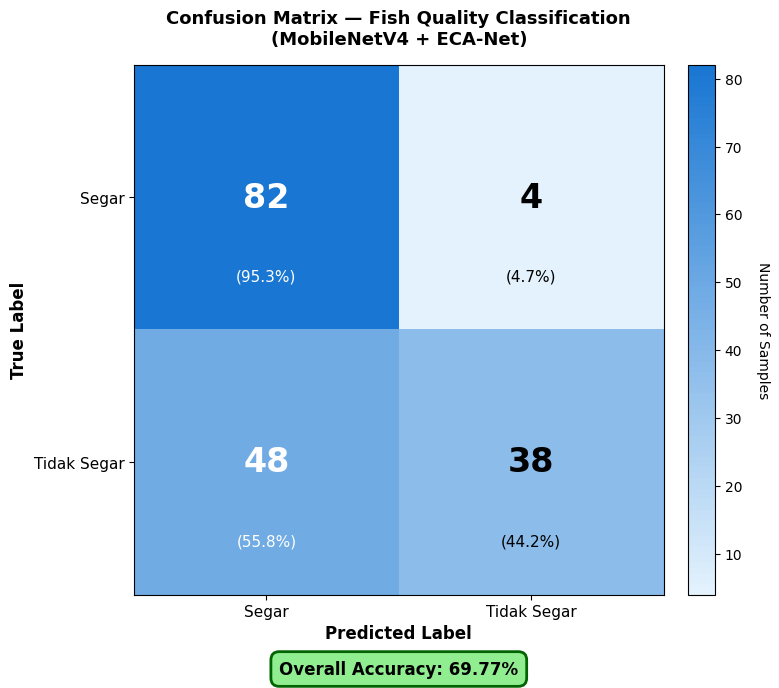


📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Segar     0.6308    0.9535    0.7593        86
 Tidak Segar     0.9048    0.4419    0.5938        86

    accuracy                         0.6977       172
   macro avg     0.7678    0.6977    0.6765       172
weighted avg     0.7678    0.6977    0.6765       172



In [13]:
def plot_confusion_matrix(y_true, y_pred, class_names=['Segar', 'Tidak Segar'], save_dir='./'):
    cm            = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(8, 7))
    cmap = LinearSegmentedColormap.from_list('custom_blue', ['#E3F2FD', '#1976D2'], N=100)
    im   = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Number of Samples', rotation=270, labelpad=20, fontsize=10)

    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks); ax.set_xticklabels(class_names, fontsize=11)
    ax.set_yticks(tick_marks); ax.set_yticklabels(class_names, fontsize=11)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i,j] > thresh else 'black'
            ax.text(j, i,     f'{cm[i,j]}',                  ha='center', va='center', color=color, fontsize=24, fontweight='bold')
            ax.text(j, i+0.3, f'({cm_normalized[i,j]*100:.1f}%)', ha='center', va='center', color=color, fontsize=11)

    ax.set_ylabel('True Label',      fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_title('Confusion Matrix — Fish Quality Classification\n(MobileNetV4 + ECA-Net)',
                 fontsize=13, fontweight='bold', pad=15)

    acc_val = accuracy_score(y_true, y_pred)
    ax.text(0.5, -0.15, f'Overall Accuracy: {acc_val*100:.2f}%', ha='center',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', edgecolor='darkgreen', linewidth=2),
            fontsize=12, fontweight='bold')

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'confusion_matrix.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'💾 Confusion matrix → {save_path}')
    plt.show()

    print('\n' + '='*70)
    print('📊 CLASSIFICATION REPORT')
    print('='*70)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    return {
        'accuracy' : acc_val,
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y_true, y_pred,    average='weighted', zero_division=0),
        'f1_score' : f1_score(y_true, y_pred,        average='weighted', zero_division=0),
        'cm'       : cm
    }


cm_metrics = plot_confusion_matrix(
    y_true, y_pred,
    class_names=['Segar', 'Tidak Segar'],
    save_dir=config.SAVE_PATH
)

# 14. ROC Curve

💾 ROC curve → /content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22/roc_curve.png


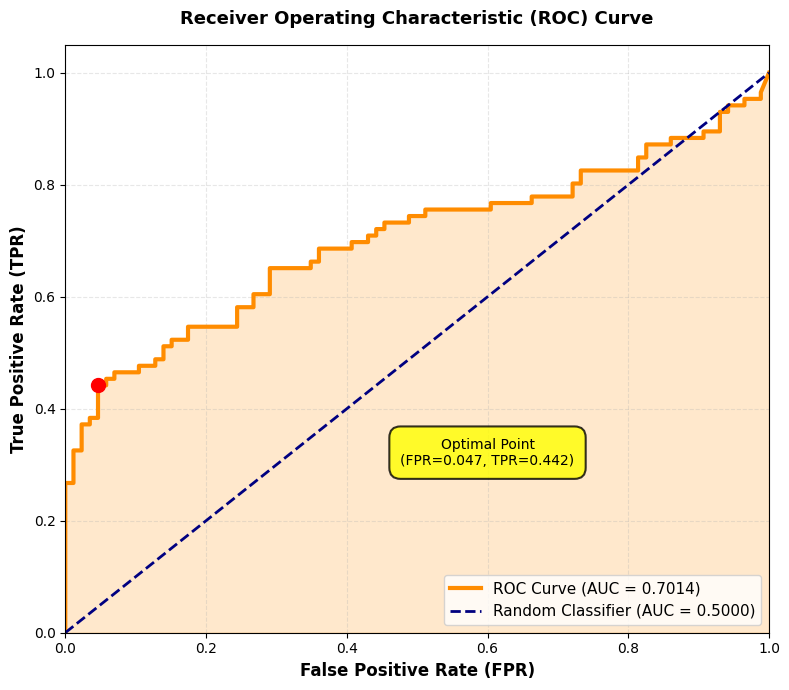


   AUC Score          : 0.7014
   Optimal Threshold  : 0.5316


In [14]:
def plot_roc_curve(y_true, y_proba, save_dir='./'):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc  = auc(fpr, tpr)
    opt_idx  = np.argmax(tpr - fpr)
    opt_fpr, opt_tpr, opt_thr = fpr[opt_idx], tpr[opt_idx], thresholds[opt_idx]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax.plot([0,1],[0,1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5000)')
    ax.fill_between(fpr, tpr, alpha=0.2, color='darkorange')
    ax.plot(opt_fpr, opt_tpr, 'ro', markersize=10)
    ax.text(0.6, 0.3, f'Optimal Point\n(FPR={opt_fpr:.3f}, TPR={opt_tpr:.3f})',
            bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow', edgecolor='black', linewidth=1.5, alpha=0.8),
            fontsize=10, ha='center')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
    ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()

    save_path = os.path.join(save_dir, 'roc_curve.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'💾 ROC curve → {save_path}')
    plt.show()
    return roc_auc, opt_thr


roc_auc, optimal_threshold = plot_roc_curve(y_true, y_proba, save_dir=config.SAVE_PATH)
print(f'\n   AUC Score          : {roc_auc:.4f}')
print(f'   Optimal Threshold  : {optimal_threshold:.4f}')

# 15. Visualisasi Sample Prediksi

💾 Sample predictions → /content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22/sample_predictions.png


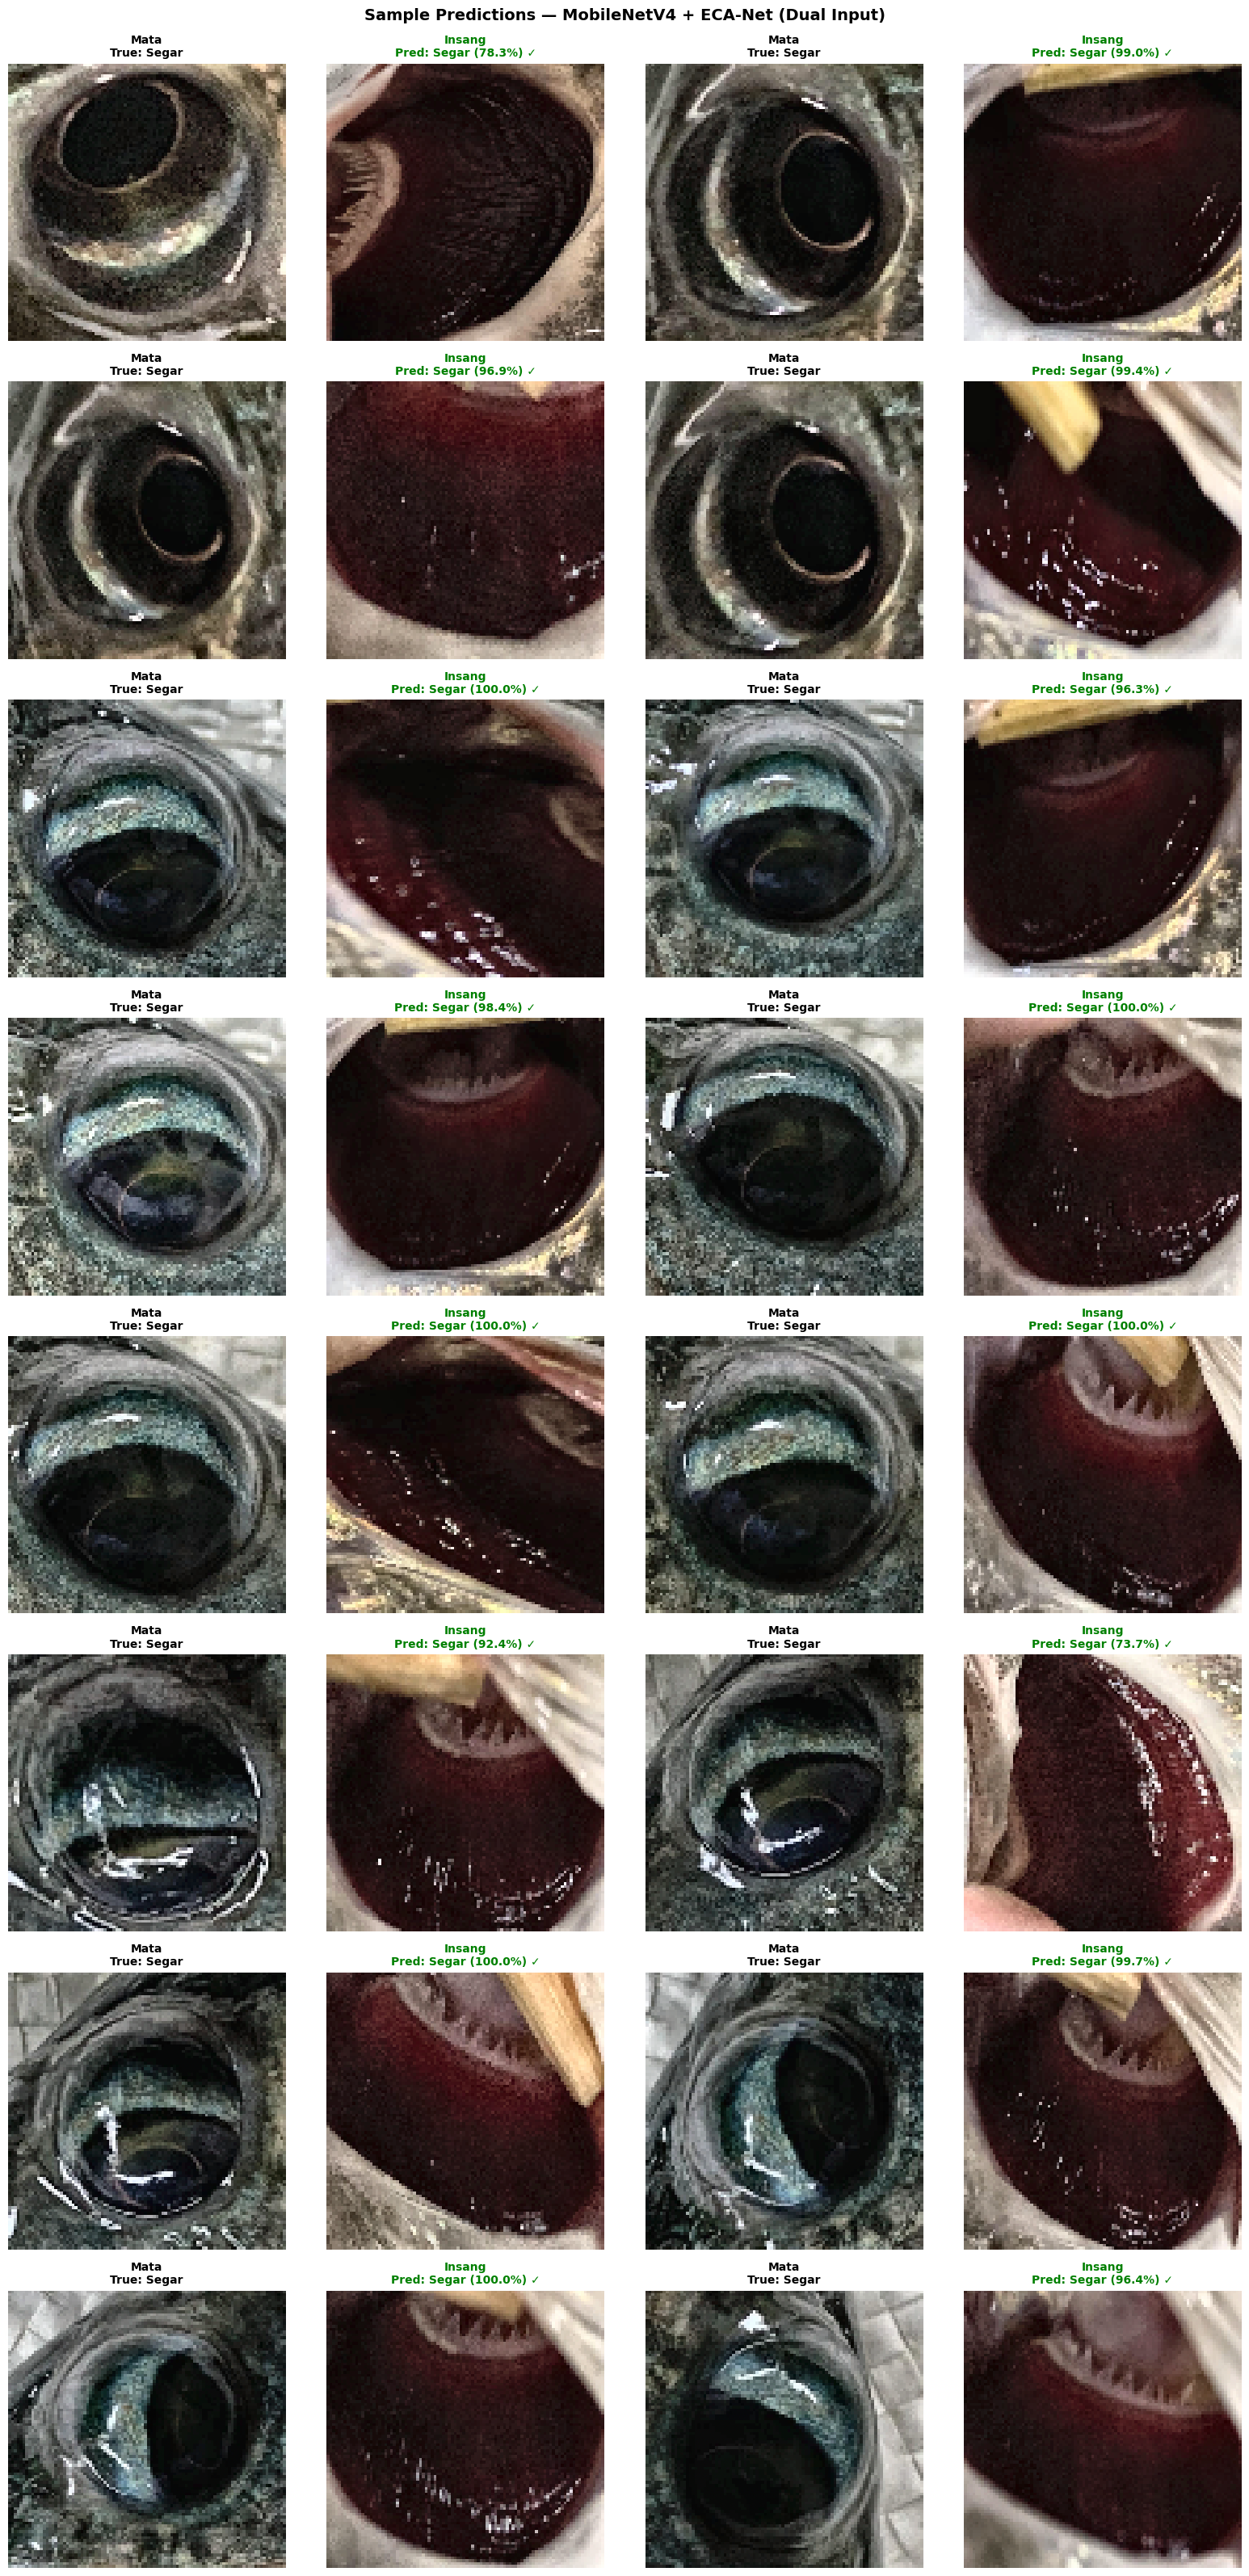

In [15]:
def visualize_sample_predictions_grid(model, dataloader, device, num_samples=16, save_dir='./'):
    model.eval()
    samples = []
    with torch.no_grad():
        for images, labels in dataloader:
            mata_img, insang_img = images
            mata_img   = mata_img.to(device)
            insang_img = insang_img.to(device)
            outputs    = model((mata_img, insang_img))
            probs      = torch.softmax(outputs, dim=1)
            preds      = torch.argmax(outputs, dim=1)
            for i in range(len(labels)):
                samples.append({
                    'mata'      : mata_img[i].cpu(),
                    'insang'    : insang_img[i].cpu(),
                    'true_label': labels[i].item(),
                    'pred_label': preds[i].item(),
                    'confidence': probs[i][preds[i]].item()
                })
                if len(samples) >= num_samples: break
            if len(samples) >= num_samples: break

    num_pairs = min(num_samples, len(samples))
    num_rows  = (num_pairs + 1) // 2
    fig, axes = plt.subplots(num_rows, 4, figsize=(16, num_rows * 4))
    if num_rows == 1: axes = axes.reshape(1, -1)
    class_names = ['Segar', 'Tidak Segar']

    for idx in range(num_pairs):
        row, col = idx // 2, (idx % 2) * 2
        s = samples[idx]
        mata   = np.clip(s['mata'].permute(1,2,0).numpy()   * np.array(config.STD) + np.array(config.MEAN), 0, 1)
        insang = np.clip(s['insang'].permute(1,2,0).numpy() * np.array(config.STD) + np.array(config.MEAN), 0, 1)
        is_correct = (s['true_label'] == s['pred_label'])
        color, status = ('green','✓') if is_correct else ('red','✗')

        axes[row, col].imshow(mata)
        axes[row, col].axis('off')
        axes[row, col].set_title(f'Mata\nTrue: {class_names[s["true_label"]]}', fontsize=10, fontweight='bold')

        axes[row, col+1].imshow(insang)
        axes[row, col+1].axis('off')
        axes[row, col+1].set_title(
            f'Insang\nPred: {class_names[s["pred_label"]]} ({s["confidence"]*100:.1f}%) {status}',
            fontsize=10, fontweight='bold', color=color
        )

    for idx in range(num_pairs, num_rows * 2):
        row, col = idx // 2, (idx % 2) * 2
        axes[row, col].axis('off'); axes[row, col+1].axis('off')

    plt.suptitle('Sample Predictions — MobileNetV4 + ECA-Net (Dual Input)',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'sample_predictions.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'💾 Sample predictions → {save_path}')
    plt.show()


visualize_sample_predictions_grid(
    model, dataloaders['test'], config.DEVICE,
    num_samples=16, save_dir=config.SAVE_PATH
)

# 16. Simpan Metrics Summary

In [16]:
report_dict  = classification_report(
    y_true, y_pred, target_names=['Segar', 'Tidak Segar'], output_dict=True
)

summary_path = os.path.join(config.SAVE_PATH, 'metrics_summary.txt')
with open(summary_path, 'w') as f:
    f.write('COMPREHENSIVE EVALUATION METRICS\n')
    f.write('Fish Quality Classification (MobileNetV4 + ECA-Net)\n')
    f.write('='*75 + '\n\n')
    f.write(f'{"Metric":<25} {"Segar":<15} {"Tidak Segar":<15} {"Overall":<10}\n')
    f.write('-'*75 + '\n')
    f.write(f'{"Precision":<25} {report_dict["Segar"]["precision"]:<15.4f} {report_dict["Tidak Segar"]["precision"]:<15.4f} {cm_metrics["precision"]:<10.4f}\n')
    f.write(f'{"Recall":<25} {report_dict["Segar"]["recall"]:<15.4f} {report_dict["Tidak Segar"]["recall"]:<15.4f} {cm_metrics["recall"]:<10.4f}\n')
    f.write(f'{"F1-Score":<25} {report_dict["Segar"]["f1-score"]:<15.4f} {report_dict["Tidak Segar"]["f1-score"]:<15.4f} {cm_metrics["f1_score"]:<10.4f}\n')
    f.write('-'*75 + '\n')
    f.write(f'{"Accuracy":<25} {"":<15} {"":<15} {cm_metrics["accuracy"]*100:<10.2f}%\n')
    f.write(f'{"AUC Score":<25} {"":<15} {"":<15} {roc_auc:<10.4f}\n')
    f.write('='*75 + '\n')
print(f'💾 Metrics summary → {summary_path}')

# ===== RINGKASAN AKHIR =====
print('\n' + '='*70)
print('✅ SEMUA OUTPUT EVALUASI TERSIMPAN')
print('='*70)
print(f'\n📂 Folder hasil: {config.SAVE_PATH}')
print(f'   ✓ confusion_matrix.png')
print(f'   ✓ roc_curve.png')
print(f'   ✓ sample_predictions.png')
print(f'   ✓ metrics_summary.txt')
print(f'   ✓ prediksi_semua_sampel.csv  ({len(df_all)} baris)')
print(f'   ✓ prediksi_benar.csv         ({len(df_benar)} baris)')
print(f'   ✓ prediksi_salah.csv         ({len(df_salah)} baris)')
print('\n🎉 EVALUASI SELESAI!')

💾 Metrics summary → /content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22/metrics_summary.txt

✅ SEMUA OUTPUT EVALUASI TERSIMPAN

📂 Folder hasil: /content/drive/MyDrive/hasilv3/Evaluations/SGD/EcaNet/22
   ✓ confusion_matrix.png
   ✓ roc_curve.png
   ✓ sample_predictions.png
   ✓ metrics_summary.txt
   ✓ prediksi_semua_sampel.csv  (172 baris)
   ✓ prediksi_benar.csv         (120 baris)
   ✓ prediksi_salah.csv         (52 baris)

🎉 EVALUASI SELESAI!
